# **Implementation of Convolutional Neural Network for ECG-Based Arrhythmia Classification**
**M Luthfi Aditya Gunandi - 1301213239**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
# The to_categorical function has been moved to tensorflow.keras.utils
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')

from scipy import interpolate

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/BerkasTA/Dataset/mitbih_train.csv/mitbih_train.csv', header=None)
test_df = pd.read_csv('/content/drive/MyDrive/BerkasTA/Dataset/mitbih_test.csv/mitbih_test.csv', header=None)

# **Preprocessing Data**

In [ ]:
train_df[187]=train_df[187].astype(int)
equilibreTrain=train_df[187].value_counts()
print(equilibreTrain)

187
0    72471
4     6431
2     5788
1     2223
3      641
Name: count, dtype: int64


In [ ]:
test_df[187]=test_df[187].astype(int)
equilibreTest=test_df[187].value_counts()
print(equilibreTest)

187
0    18118
4     1608
2     1448
1      556
3      162
Name: count, dtype: int64


In [ ]:
# format persentase dan membesarkan ukuran font
def make_autopct(fontsize):
    def my_autopct(pct):
        return f'{pct:.1f}%'
    return lambda pct: my_autopct(pct)

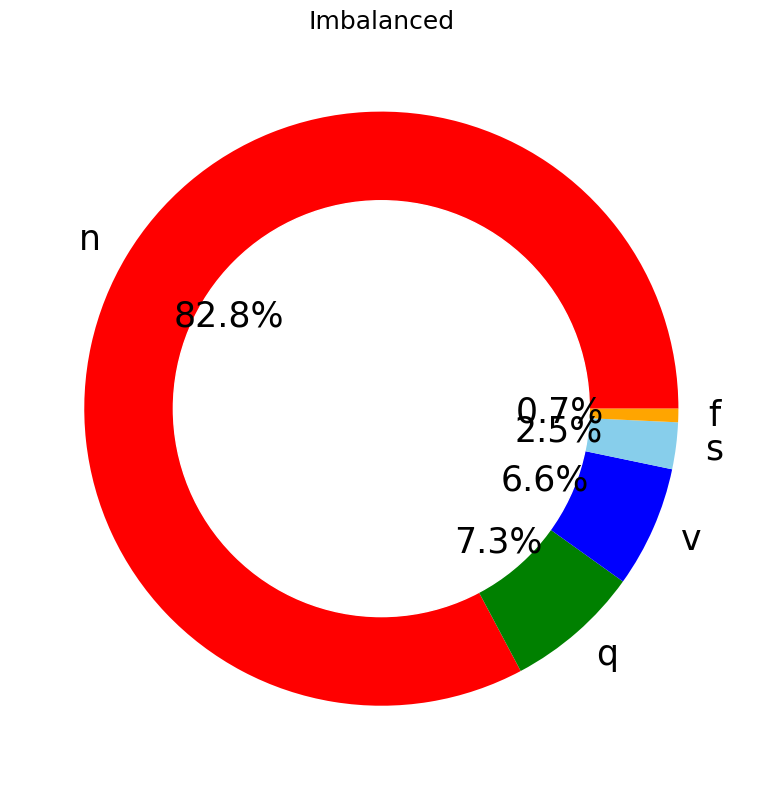

In [ ]:
# Pie chart 1 (imbalanced)
plt.figure(figsize=(8, 8))
my_circle = plt.Circle((0, 0), 0.7, color='white')
plt.pie(
    equilibreTrain,
    labels=['n', 'q', 'v', 's', 'f'],
    colors=['red', 'green', 'blue', 'skyblue', 'orange'],
    autopct=make_autopct(16),
    textprops={'fontsize': 25}
)
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title('Imbalanced', fontsize=18)
plt.tight_layout()
plt.show()

**BALANCING DATA**

In [ ]:
from sklearn.utils import resample
df_1=train_df[train_df[187]==1]
df_2=train_df[train_df[187]==2]
df_3=train_df[train_df[187]==3]
df_4=train_df[train_df[187]==4]
df_0=(train_df[train_df[187]==0]).sample(n=20000,random_state=42)

df_1_upsample=resample(df_1,replace=True,n_samples=20000,random_state=123)
df_2_upsample=resample(df_2,replace=True,n_samples=20000,random_state=124)
df_3_upsample=resample(df_3,replace=True,n_samples=20000,random_state=125)
df_4_upsample=resample(df_4,replace=True,n_samples=20000,random_state=126)

train_df=pd.concat([df_0,df_1_upsample,df_2_upsample,df_3_upsample,df_4_upsample])

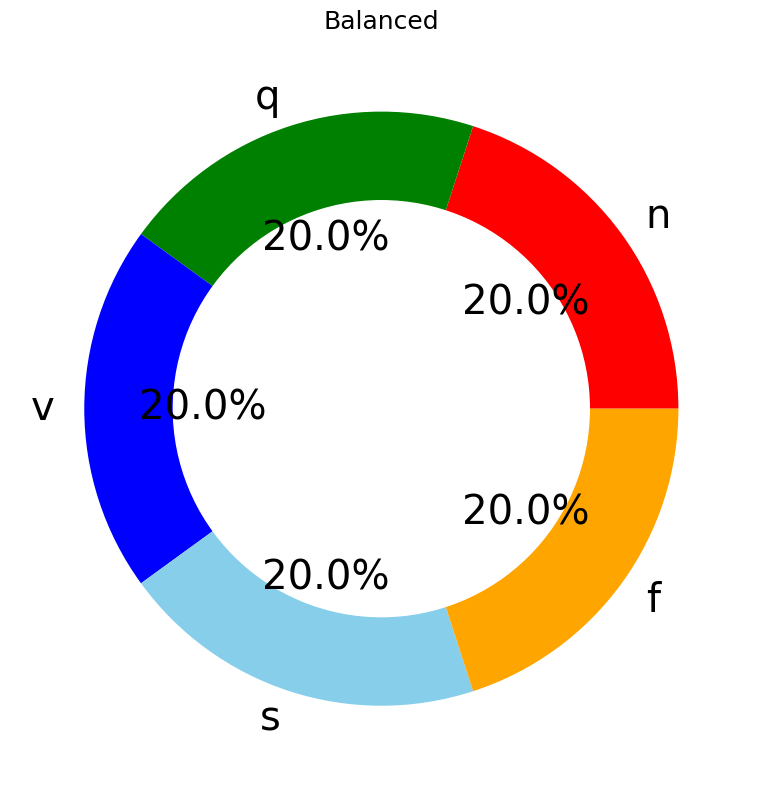

In [ ]:
# Pie chart 2 (balanced)
plt.figure(figsize=(8, 8))
my_circle = plt.Circle((0, 0), 0.7, color='white')
plt.pie(
    equilibreTrain,
    labels=['n', 'q', 'v', 's', 'f'],
    colors=['red', 'green', 'blue', 'skyblue', 'orange'],
    autopct=make_autopct(16),
    textprops={'fontsize': 29}
)
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title('Balanced', fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
dft_1=test_df[test_df[187]==1]
dft_2=test_df[test_df[187]==2]
dft_3=test_df[test_df[187]==3]
dft_4=test_df[test_df[187]==4]
dft_0=(test_df[test_df[187]==0]).sample(n=10000,random_state=42)

dft_1_upsample=resample(df_1,replace=True,n_samples=10000,random_state=123)
dft_2_upsample=resample(df_2,replace=True,n_samples=10000,random_state=124)
dft_3_upsample=resample(df_3,replace=True,n_samples=10000,random_state=125)
dft_4_upsample=resample(df_4,replace=True,n_samples=10000,random_state=126)

test_df=pd.concat([dft_0,dft_1_upsample,dft_2_upsample,dft_3_upsample,dft_4_upsample])

In [ ]:
equilibreTrain=train_df[187].value_counts()
print(equilibreTrain)

187
0    20000
1    20000
2    20000
3    20000
4    20000
Name: count, dtype: int64


In [ ]:
equilibreTest=test_df[187].value_counts()
print(equilibreTest)

187
0    10000
1    10000
2    10000
3    10000
4    10000
Name: count, dtype: int64


In [ ]:
c=train_df.groupby(187,group_keys=False).apply(lambda train_df : train_df.sample(1))

In [ ]:
c

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
45572,0.722222,0.547840,0.300926,0.157407,0.115741,0.143519,0.140432,0.155864,0.185185,0.168210,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
74545,1.000000,0.941634,0.330739,0.042802,0.093385,0.159533,0.167315,0.217899,0.252918,0.214008,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
75803,0.000000,0.042618,0.140030,0.304414,0.336377,0.496195,0.631659,0.573820,0.668189,0.554033,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
80569,1.000000,0.952073,0.735751,0.430052,0.194301,0.138601,0.139896,0.112694,0.095855,0.082902,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
84843,0.911765,0.804813,0.711230,0.585562,0.513369,0.462567,0.545455,0.510695,0.478610,0.326203,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


**Visualisasi Single Data Sample**

In [ ]:
def plot_hist(class_number,size,min_,bins):
    img=train_df.loc[train_df[187]==class_number].values
    img=img[:,min_:size]
    img_flatten=img.flatten()

    final1=np.arange(min_,size)
    for i in range (img.shape[0]-1):
        tempo1=np.arange(min_,size)
        final1=np.concatenate((final1, tempo1), axis=None)
    print(len(final1))
    print(len(img_flatten))
    plt.hist2d(final1,img_flatten, bins=(bins,bins),cmap=plt.cm.jet)
    plt.show()

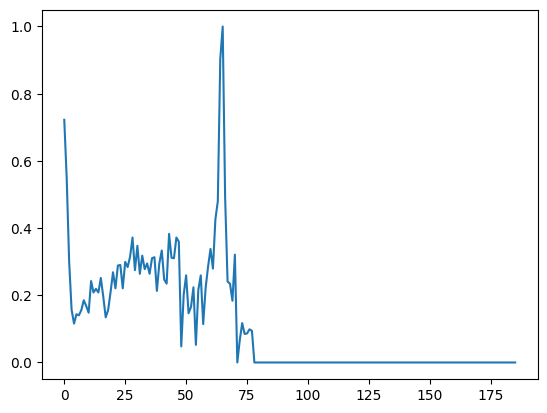

In [ ]:
plt.plot(c.iloc[0,:186])

1300000
1300000


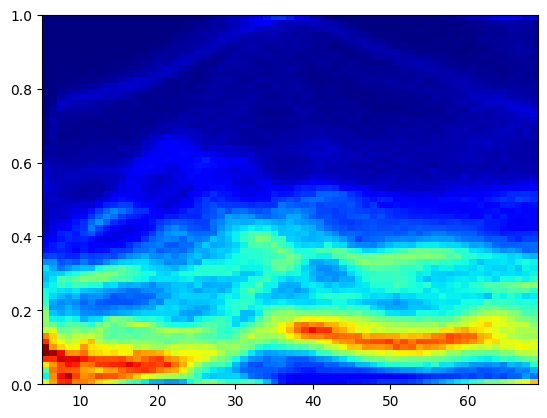

In [ ]:
plot_hist(0,70,5,65)

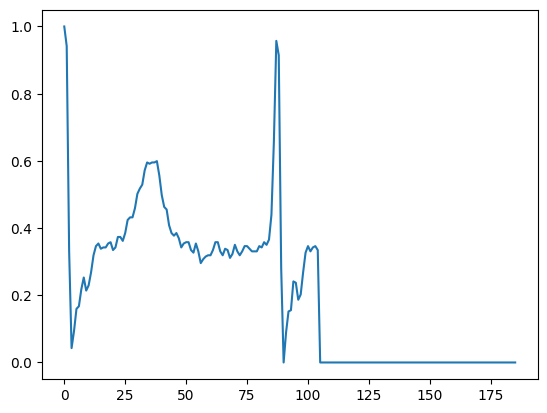

In [ ]:
plt.plot(c.iloc[1,:186])

900000
900000


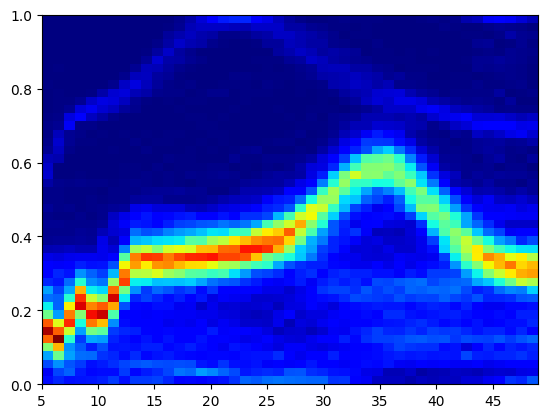

In [ ]:
plot_hist(1,50,5,45)

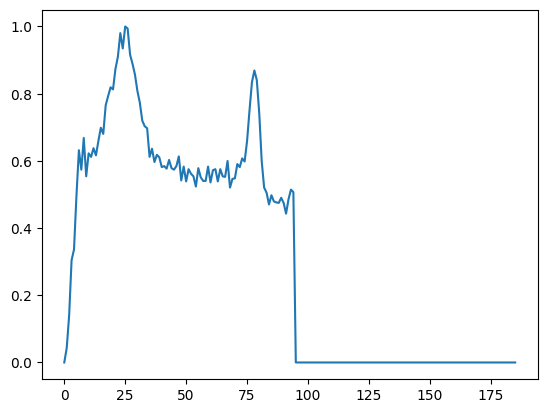

In [ ]:
plt.plot(c.iloc[2,:186])

900000
900000


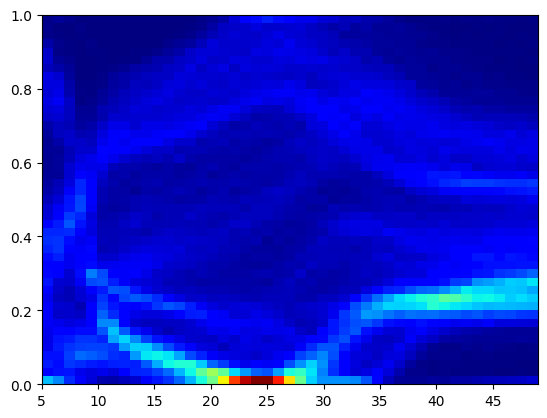

In [ ]:
plot_hist(2,50,5,45)

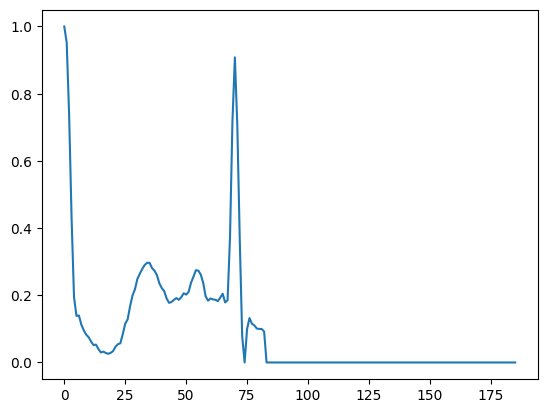

In [ ]:
plt.plot(c.iloc[3,:186])

900000
900000


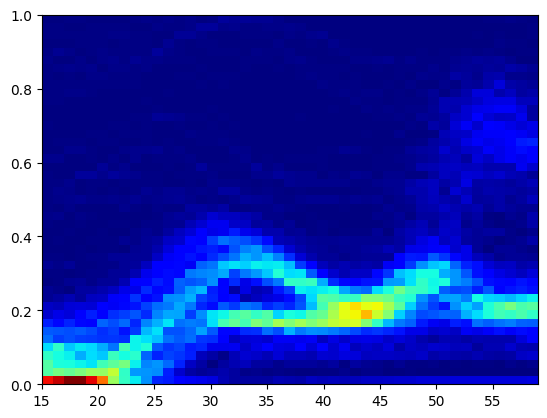

In [ ]:
plot_hist(3,60,15,45)

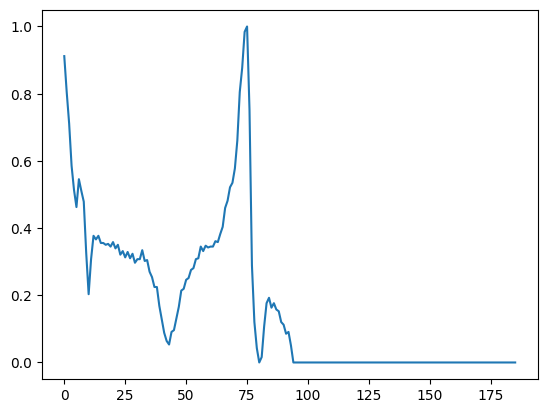

In [ ]:
plt.plot(c.iloc[4,:186])

700000
700000


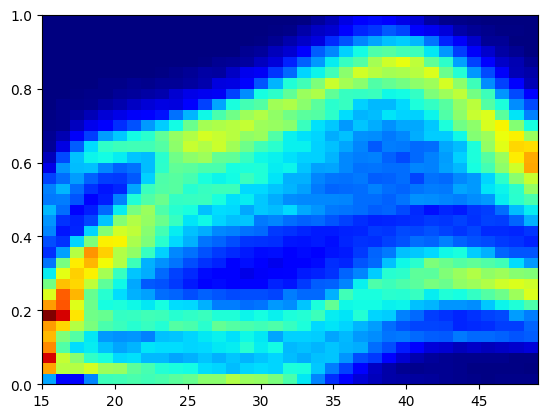

In [ ]:
plot_hist(4,50,15,35)

# **Augmentation Data - Time Warping, Magnitude Warping**

In [ ]:
def time_warping(signal, sigma=0.2, knot=4):
    """
    Time warping: Sedikit regangkan atau kompres sinyal EKG dalam domain waktu
    untuk mensimulasikan variasi laju jantung.

    Parameters:
    - signal: sinyal EKG 1D
    - sigma: standar deviasi untuk kontrol warping (default: 0.2)
    - knot: jumlah titik kontrol untuk warping (default: 4)
    """
    orig_steps = np.arange(len(signal))

    # Buat titik kontrol yang acak
    random_warps = np.random.normal(loc=1.0, scale=sigma, size=(knot+2,))
    warp_steps = (np.ones((len(signal),))*(len(signal)-1))/(knot+1)
    warp_steps = np.linspace(0, len(signal)-1, knot+2)

    # Pastikan titik kontrol tetap dalam urutan yang benar
    random_warps = np.cumsum(random_warps)
    random_warps = random_warps / random_warps[-1] * (len(signal) - 1)

    # Interpolasi untuk mendapatkan warping function
    warper = np.interp(orig_steps, warp_steps, random_warps)

    # Terapkan warping menggunakan interpolasi
    warped_signal = np.interp(orig_steps, warper, signal)

    return warped_signal

In [ ]:
def magnitude_warping(signal, sigma=0.2, knot=4):
    """
    Magnitude warping: Ubah amplitudo gelombang secara lokal untuk meniru
    perbedaan kekuatan sinyal.

    Parameters:
    - signal: sinyal EKG 1D
    - sigma: standar deviasi untuk kontrol warping (default: 0.2)
    - knot: jumlah titik kontrol untuk warping (default: 4)
    """
    orig_steps = np.arange(len(signal))

    # Buat multiplier acak untuk setiap titik kontrol
    random_warps = np.random.normal(loc=1.0, scale=sigma, size=(knot+2,))
    warp_steps = np.linspace(0, len(signal)-1, knot+2)

    # Interpolasi untuk mendapatkan smooth magnitude warping
    warper = np.interp(orig_steps, warp_steps, random_warps)

    # Terapkan magnitude warping
    warped_signal = signal * warper

    return warped_signal

In [ ]:
def combined_augmentation(signal, time_sigma=0.2, mag_sigma=0.2, knot=4, apply_prob=0.7):
    """
    Kombinasi time warping dan magnitude warping dengan probabilitas tertentu.

    Parameters:
    - signal: sinyal EKG 1D
    - time_sigma: standar deviasi untuk time warping
    - mag_sigma: standar deviasi untuk magnitude warping
    - knot: jumlah titik kontrol
    - apply_prob: probabilitas untuk menerapkan augmentasi
    """
    augmented_signal = signal.copy()

    # Terapkan time warping dengan probabilitas tertentu
    if np.random.random() < apply_prob:
        augmented_signal = time_warping(augmented_signal, time_sigma, knot)

    # Terapkan magnitude warping dengan probabilitas tertentu
    if np.random.random() < apply_prob:
        augmented_signal = magnitude_warping(augmented_signal, mag_sigma, knot)

    return augmented_signal

In [ ]:
# Demonstrasi augmentasi
tempo = c.iloc[0,:186]

# Time warping
time_warped = time_warping(tempo, sigma=0.3, knot=4)

# Magnitude warping
mag_warped = magnitude_warping(tempo, sigma=0.3, knot=4)

# Combined augmentation
combined_aug = combined_augmentation(tempo, time_sigma=0.2, mag_sigma=0.2, knot=4)

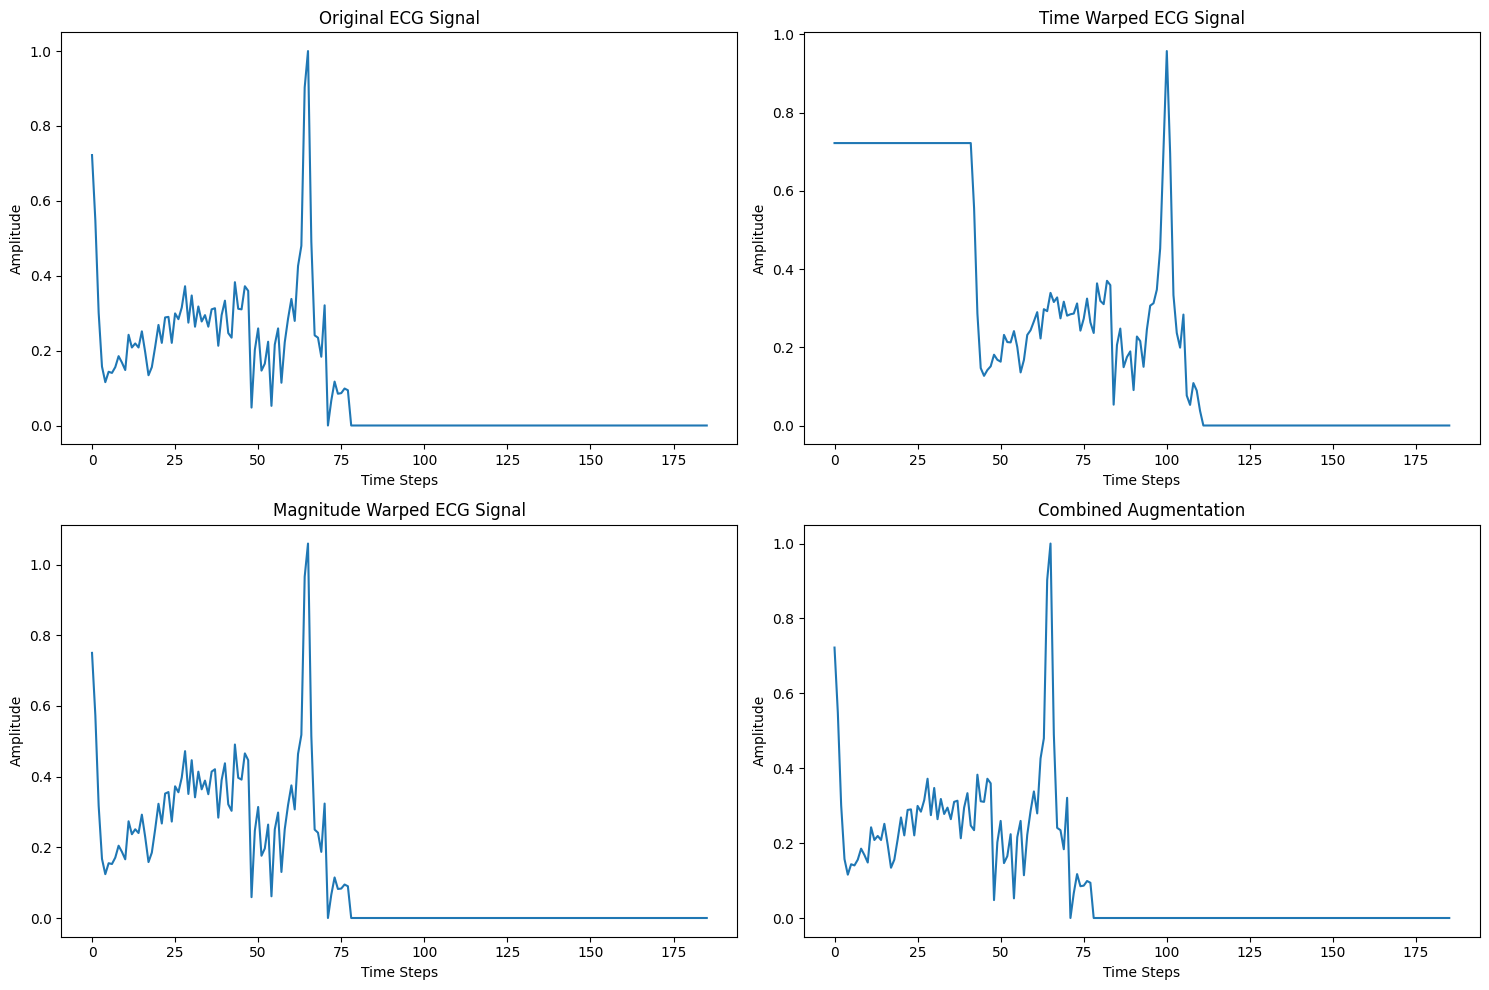

In [ ]:
# Visualisasi perbandingan
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(tempo)
plt.title('Original ECG Signal', fontsize=12)
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 2)
plt.plot(time_warped)
plt.title('Time Warped ECG Signal', fontsize=12)
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 3)
plt.plot(mag_warped)
plt.title('Magnitude Warped ECG Signal', fontsize=12)
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 4)
plt.plot(combined_aug)
plt.title('Combined Augmentation', fontsize=12)
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

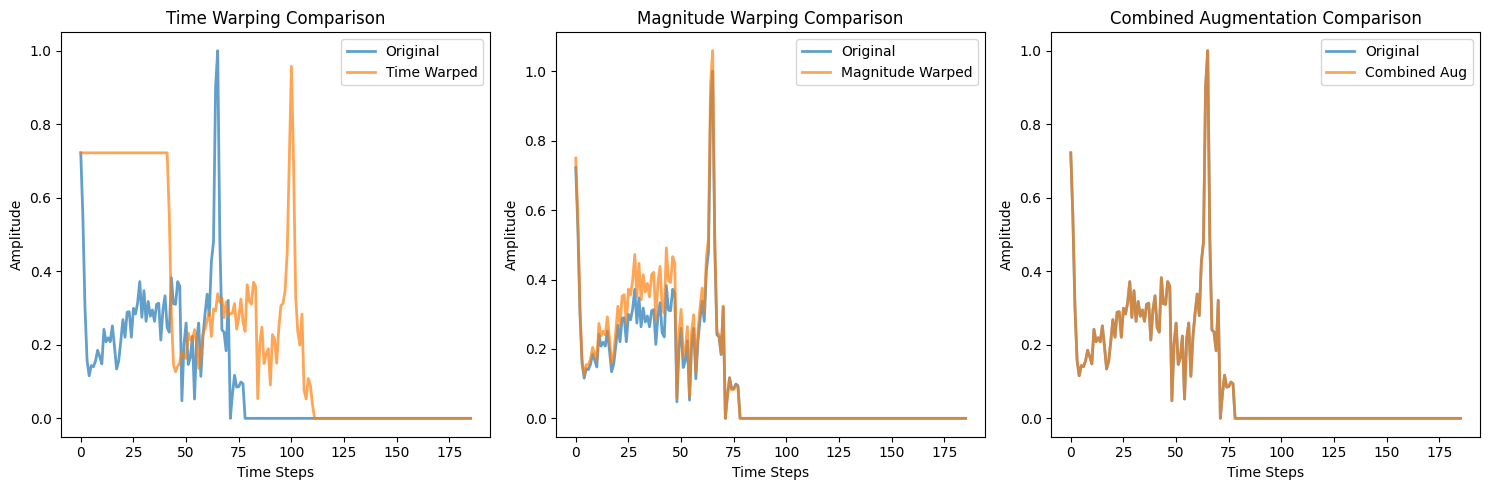

In [ ]:
# Perbandingan overlay untuk melihat perbedaan lebih jelas
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(tempo, label='Original', alpha=0.7, linewidth=2)
plt.plot(time_warped, label='Time Warped', alpha=0.7, linewidth=2)
plt.title('Time Warping Comparison')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(tempo, label='Original', alpha=0.7, linewidth=2)
plt.plot(mag_warped, label='Magnitude Warped', alpha=0.7, linewidth=2)
plt.title('Magnitude Warping Comparison')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(tempo, label='Original', alpha=0.7, linewidth=2)
plt.plot(combined_aug, label='Combined Aug', alpha=0.7, linewidth=2)
plt.title('Combined Augmentation Comparison')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()

**Convert Label & One-hot Encoding**

In [ ]:
target_train=train_df[187]
target_test=test_df[187]
y_train=to_categorical(target_train)
y_test=to_categorical(target_test)

In [ ]:
X_train=train_df.iloc[:,:186].values
X_test=test_df.iloc[:,:186].values

# Terapkan augmentasi cerdas pada data training
print("Applying intelligent augmentation to training data...")
for i in range(len(X_train)):
    X_train[i,:186] = combined_augmentation(
        X_train[i,:186],
        time_sigma=0.2,
        mag_sigma=0.15,
        knot=4,
        apply_prob=0.8
    )

X_train = X_train.reshape(len(X_train), X_train.shape[1],1)
X_test = X_test.reshape(len(X_test), X_test.shape[1],1)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Applying intelligent augmentation to training data...
Training data shape: (100000, 186, 1)
Test data shape: (50000, 186, 1)


# **Convolutional Neural Network**

In [ ]:
# Import tambahan untuk hyperparameter tuning
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.layers import Dropout
import itertools
from datetime import datetime
import json

In [ ]:
def create_cnn_model(input_shape, config):
    """
    Membuat model CNN dengan konfigurasi hyperparameter yang dapat disesuaikan

    Parameters:
    - input_shape: bentuk input data
    - config: dictionary berisi hyperparameter
    """
    inputs_cnn = Input(shape=input_shape, name='inputs_cnn')
    x = inputs_cnn

    # Convolutional layers dengan hyperparameter tuning
    for i, layer_config in enumerate(config['conv_layers']):
        x = Convolution1D(
            filters=layer_config['filters'],
            kernel_size=layer_config['kernel_size'],
            activation=layer_config['activation'],
            kernel_regularizer=layer_config.get('regularizer', None)
        )(x)

        if config['use_batch_norm']:
            x = BatchNormalization()(x)

        if layer_config.get('dropout', 0) > 0:
            x = Dropout(layer_config['dropout'])(x)

        x = MaxPool1D(
            pool_size=layer_config['pool_size'],
            strides=layer_config['strides'],
            padding="same"
        )(x)

    # Flatten layer
    x = Flatten()(x)

    # Dense layers dengan hyperparameter tuning
    for dense_config in config['dense_layers']:
        x = Dense(
            units=dense_config['units'],
            activation=dense_config['activation'],
            kernel_regularizer=dense_config.get('regularizer', None)
        )(x)

        if dense_config.get('dropout', 0) > 0:
            x = Dropout(dense_config['dropout'])(x)

    # Output layer
    main_output = Dense(5, activation='softmax', name='main_output')(x)

    # Create model
    model = Model(inputs=inputs_cnn, outputs=main_output)

    # Compile model dengan optimizer yang dapat disesuaikan
    optimizer_map = {
        'adam': Adam(learning_rate=config['learning_rate']),
        'rmsprop': RMSprop(learning_rate=config['learning_rate']),
        'sgd': SGD(learning_rate=config['learning_rate'])
    }

    model.compile(
        optimizer=optimizer_map[config['optimizer']],
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def train_model_with_config(X_train, y_train, X_test, y_test, config, model_name):
    """
    Melatih model dengan konfigurasi tertentu dan menyimpan hasil
    """
    print(f"\n{'='*50}")
    print(f"Training Model: {model_name}")
    print(f"{'='*50}")

    # Create model
    model = create_cnn_model((X_train.shape[1], 1), config)

    # Print model summary
    print(f"Model Configuration: {model_name}")
    model.summary()

    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=config['patience'],
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=f'best_model_{model_name}.keras',
            monitor='val_loss',
            save_best_only=True
        )
    ]

    # Train model
    start_time = datetime.now()
    history = model.fit(
        X_train, y_train,
        epochs=config['epochs'],
        callbacks=callbacks,
        batch_size=config['batch_size'],
        validation_data=(X_test, y_test),
        verbose=1
    )
    end_time = datetime.now()

    training_time = (end_time - start_time).total_seconds()

    # Load best weights
    model.load_weights(f'best_model_{model_name}.keras')

    # Evaluate model
    train_score = model.evaluate(X_train, y_train, verbose=0)
    test_score = model.evaluate(X_test, y_test, verbose=0)

    results = {
        'model_name': model_name,
        'config': config,
        'train_loss': train_score[0],
        'train_accuracy': train_score[1],
        'test_loss': test_score[0],
        'test_accuracy': test_score[1],
        'training_time': training_time,
        'total_epochs': len(history.history['loss'])
    }

    print(f"Training completed in {training_time:.2f} seconds")
    print(f"Train Accuracy: {train_score[1]*100:.2f}%")
    print(f"Test Accuracy: {test_score[1]*100:.2f}%")

    return model, history, results

**DEFINISI SKENARIO EKSPERIMEN**

In [ ]:
# Baseline Model (Original)
baseline_config = {
    'conv_layers': [
        {'filters': 64, 'kernel_size': 6, 'activation': 'relu', 'pool_size': 3, 'strides': 2, 'dropout': 0},
        {'filters': 64, 'kernel_size': 3, 'activation': 'relu', 'pool_size': 2, 'strides': 2, 'dropout': 0},
        {'filters': 64, 'kernel_size': 3, 'activation': 'relu', 'pool_size': 2, 'strides': 2, 'dropout': 0}
    ],
    'dense_layers': [
        {'units': 64, 'activation': 'relu', 'dropout': 0},
        {'units': 32, 'activation': 'relu', 'dropout': 0}
    ],
    'optimizer': 'adam',
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 40,
    'patience': 8,
    'use_batch_norm': True
}

# Deeper Network
deeper_config = {
    'conv_layers': [
        {'filters': 32, 'kernel_size': 7, 'activation': 'relu', 'pool_size': 2, 'strides': 1, 'dropout': 0.1},
        {'filters': 64, 'kernel_size': 5, 'activation': 'relu', 'pool_size': 2, 'strides': 2, 'dropout': 0.1},
        {'filters': 128, 'kernel_size': 3, 'activation': 'relu', 'pool_size': 2, 'strides': 2, 'dropout': 0.2},
        {'filters': 256, 'kernel_size': 3, 'activation': 'relu', 'pool_size': 2, 'strides': 2, 'dropout': 0.2}
    ],
    'dense_layers': [
        {'units': 128, 'activation': 'relu', 'dropout': 0.3},
        {'units': 64, 'activation': 'relu', 'dropout': 0.3},
        {'units': 32, 'activation': 'relu', 'dropout': 0.2}
    ],
    'optimizer': 'adam',
    'learning_rate': 0.0005,
    'batch_size': 64,
    'epochs': 50,
    'patience': 10,
    'use_batch_norm': True
}

# Optimized Model dengan Regularization
optimized_config = {
    'conv_layers': [
        {'filters': 128, 'kernel_size': 5, 'activation': 'relu', 'pool_size': 2, 'strides': 2,
         'dropout': 0.15, 'regularizer': l2(0.001)},
        {'filters': 256, 'kernel_size': 3, 'activation': 'relu', 'pool_size': 2, 'strides': 2,
         'dropout': 0.2, 'regularizer': l2(0.001)},
        {'filters': 128, 'kernel_size': 3, 'activation': 'relu', 'pool_size': 2, 'strides': 2,
         'dropout': 0.2, 'regularizer': l2(0.001)}
    ],
    'dense_layers': [
        {'units': 256, 'activation': 'relu', 'dropout': 0.4, 'regularizer': l2(0.001)},
        {'units': 128, 'activation': 'relu', 'dropout': 0.3, 'regularizer': l2(0.001)}
    ],
    'optimizer': 'adam',
    'learning_rate': 0.0008,
    'batch_size': 48,
    'epochs': 60,
    'patience': 12,
    'use_batch_norm': True
}

# Lightweight Model
lightweight_config = {
    'conv_layers': [
        {'filters': 32, 'kernel_size': 8, 'activation': 'relu', 'pool_size': 4, 'strides': 2, 'dropout': 0},
        {'filters': 64, 'kernel_size': 4, 'activation': 'relu', 'pool_size': 3, 'strides': 2, 'dropout': 0.1}
    ],
    'dense_layers': [
        {'units': 64, 'activation': 'relu', 'dropout': 0.2}
    ],
    'optimizer': 'rmsprop',
    'learning_rate': 0.002,
    'batch_size': 128,
    'epochs': 30,
    'patience': 6,
    'use_batch_norm': False
}

# Eksperimen dengan Different Optimizer
sgd_config = {
    'conv_layers': [
        {'filters': 96, 'kernel_size': 6, 'activation': 'relu', 'pool_size': 3, 'strides': 2, 'dropout': 0.1},
        {'filters': 128, 'kernel_size': 3, 'activation': 'relu', 'pool_size': 2, 'strides': 2, 'dropout': 0.15},
        {'filters': 96, 'kernel_size': 3, 'activation': 'relu', 'pool_size': 2, 'strides': 2, 'dropout': 0.15}
    ],
    'dense_layers': [
        {'units': 128, 'activation': 'relu', 'dropout': 0.3},
        {'units': 64, 'activation': 'relu', 'dropout': 0.2}
    ],
    'optimizer': 'sgd',
    'learning_rate': 0.01,
    'batch_size': 32,
    'epochs': 45,
    'patience': 10,
    'use_batch_norm': True
}

# Dictionary untuk menyimpan semua konfigurasi
experiment_configs = {
    'baseline': baseline_config,
    'deeper': deeper_config,
    'optimized': optimized_config,
    'lightweight': lightweight_config,
    'sgd_optimizer': sgd_config
}

# **Model Evaluation**

In [ ]:
"""# ===== PERUBAHAN 6: MODEL EVALUATION YANG DIPERLUAS =====
# **Enhanced Model Evaluation with Comparison**"""

def evaluate_model_detailed(history, X_test, y_test, model, model_name="Model"):
    """
    Evaluasi model yang lebih detail dengan visualisasi yang diperbaiki
    """
    scores = model.evaluate(X_test, y_test, verbose=0)
    print(f"{model_name} - Test Accuracy: {scores[1]*100:.2f}%")
    print(f"{model_name} - Test Loss: {scores[0]:.4f}")

    # Plot training history dengan styling yang lebih baik
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy plot
    ax1.plot(history.history['accuracy'], 'b-', linewidth=2, label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2.plot(history.history['loss'], 'b-', linewidth=2, label='Training Loss')
    ax2.plot(history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return scores

def compare_models(models_results):
    """
    Membandingkan hasil dari multiple models
    """
    print("\n" + "="*80)
    print("MODEL COMPARISON RESULTS")
    print("="*80)

    # Create comparison DataFrame
    comparison_data = []
    for result in models_results:
        comparison_data.append({
            'Model': result['model_name'],
            'Train Acc (%)': f"{result['train_accuracy']*100:.2f}",
            'Test Acc (%)': f"{result['test_accuracy']*100:.2f}",
            'Train Loss': f"{result['train_loss']:.4f}",
            'Test Loss': f"{result['test_loss']:.4f}",
            'Training Time (s)': f"{result['training_time']:.1f}",
            'Epochs': result['total_epochs']
        })

    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))

    # Visualisasi perbandingan
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    model_names = [result['model_name'] for result in models_results]
    test_accuracies = [result['test_accuracy']*100 for result in models_results]
    test_losses = [result['test_loss'] for result in models_results]
    training_times = [result['training_time'] for result in models_results]
    total_epochs = [result['total_epochs'] for result in models_results]

    # Test Accuracy Comparison
    bars1 = axes[0,0].bar(model_names, test_accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57'])
    axes[0,0].set_title('Test Accuracy Comparison', fontweight='bold')
    axes[0,0].set_ylabel('Accuracy (%)')
    axes[0,0].tick_params(axis='x', rotation=45)
    for bar, acc in zip(bars1, test_accuracies):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                      f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

    # Test Loss Comparison
    bars2 = axes[0,1].bar(model_names, test_losses, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57'])
    axes[0,1].set_title('Test Loss Comparison', fontweight='bold')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].tick_params(axis='x', rotation=45)
    for bar, loss in zip(bars2, test_losses):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                      f'{loss:.4f}', ha='center', va='bottom', fontweight='bold')

    # Training Time Comparison
    bars3 = axes[1,0].bar(model_names, training_times, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57'])
    axes[1,0].set_title('Training Time Comparison', fontweight='bold')
    axes[1,0].set_ylabel('Time (seconds)')
    axes[1,0].tick_params(axis='x', rotation=45)
    for bar, time in zip(bars3, training_times):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                      f'{time:.1f}s', ha='center', va='bottom', fontweight='bold')

    # Epochs Comparison
    bars4 = axes[1,1].bar(model_names, total_epochs, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57'])
    axes[1,1].set_title('Training Epochs Comparison', fontweight='bold')
    axes[1,1].set_ylabel('Epochs')
    axes[1,1].tick_params(axis='x', rotation=45)
    for bar, epoch in zip(bars4, total_epochs):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                      f'{epoch}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Find best model
    best_model_idx = np.argmax(test_accuracies)
    best_model = models_results[best_model_idx]
    print(f"\n🏆 BEST MODEL: {best_model['model_name']}")
    print(f"   Test Accuracy: {best_model['test_accuracy']*100:.2f}%")
    print(f"   Training Time: {best_model['training_time']:.1f} seconds")

    return df_comparison

**Training Data**

🚀 STARTING HYPERPARAMETER TUNING EXPERIMENTS

🔄 Running experiment: BASELINE

Training Model: baseline
Model Configuration: baseline


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs_cnn (InputLayer)         │ (None, 186, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 181, 64)        │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 181, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 91, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 89, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 89, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 43, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 43, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        90,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_output (Dense)             │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,341 (462.27 KB)

 Trainable params: 117,957 (460.77 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 109s 33ms/step - accuracy: 0.7932 - loss: 0.5567 - val_accuracy: 0.8581 - val_loss: 0.3885
Epoch 2/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 117s 37ms/step - accuracy: 0.9065 - loss: 0.2539 - val_accuracy: 0.8770 - val_loss: 0.3525
Epoch 3/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 127s 33ms/step - accuracy: 0.9300 - loss: 0.1905 - val_accuracy: 0.9479 - val_loss: 0.1527
Epoch 4/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 151s 36ms/step - accuracy: 0.9428 - loss: 0.1545 - val_accuracy: 0.9557 - val_loss: 0.1373
Epoch 5/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 102s 33ms/step - accuracy: 0.9524 - loss: 0.1296 - val_accuracy: 0.9646 - val_loss: 0.1061
Epoch 6/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 151s 35ms/step - accuracy: 0.9580 - loss: 0.1120 - val_accuracy: 0.9578 - val_loss: 0.1245
Epoch 7/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 134s 33ms/step - accuracy: 0.9638 - loss: 0.0969 - val_accuracy: 0.9623 - val_loss: 0.1122
Epoch 8/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 150s 36ms/step - accuracy: 

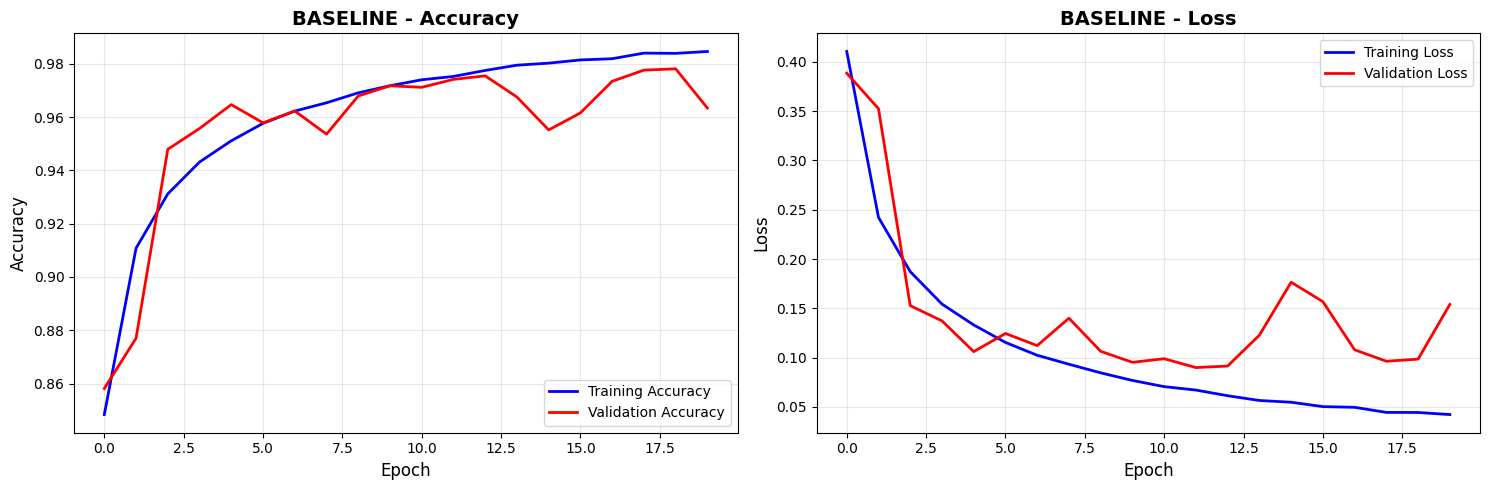


🔄 Running experiment: OPTIMIZED

Training Model: optimized
Model Configuration: optimized


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs_cnn (InputLayer)         │ (None, 186, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 182, 128)       │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 182, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 182, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 91, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 89, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 89, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 89, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 45, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 43, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 43, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       721,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_output (Dense)             │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 954,501 (3.64 MB)

 Trainable params: 953,477 (3.64 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/60
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 445s 211ms/step - accuracy: 0.6813 - loss: 1.6231 - val_accuracy: 0.8113 - val_loss: 0.8212
Epoch 2/60
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 430s 206ms/step - accuracy: 0.8530 - loss: 0.7192 - val_accuracy: 0.8957 - val_loss: 0.5563
Epoch 3/60
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 434s 208ms/step - accuracy: 0.8791 - loss: 0.6115 - val_accuracy: 0.8910 - val_loss: 0.5684
Epoch 4/60
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 431s 207ms/step - accuracy: 0.8885 - loss: 0.5814 - val_accuracy: 0.8706 - val_loss: 0.6029
Epoch 5/60
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 432s 202ms/step - accuracy: 0.8965 - loss: 0.5451 - val_accuracy: 0.9187 - val_loss: 0.4767
Epoch 6/60
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 440s 201ms/step - accuracy: 0.9011 - loss: 0.5316 - val_accuracy: 0.9279 - val_loss: 0.4378
Epoch 7/60
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 447s 203ms/step - accuracy: 0.9031 - loss: 0.5116 - val_accuracy: 0.9309 - val_loss: 0.4196
Epoch 8/60
2084/2084 ━━━━━━━━━━━━━━━━━━━━ 427s 205ms/step - ac

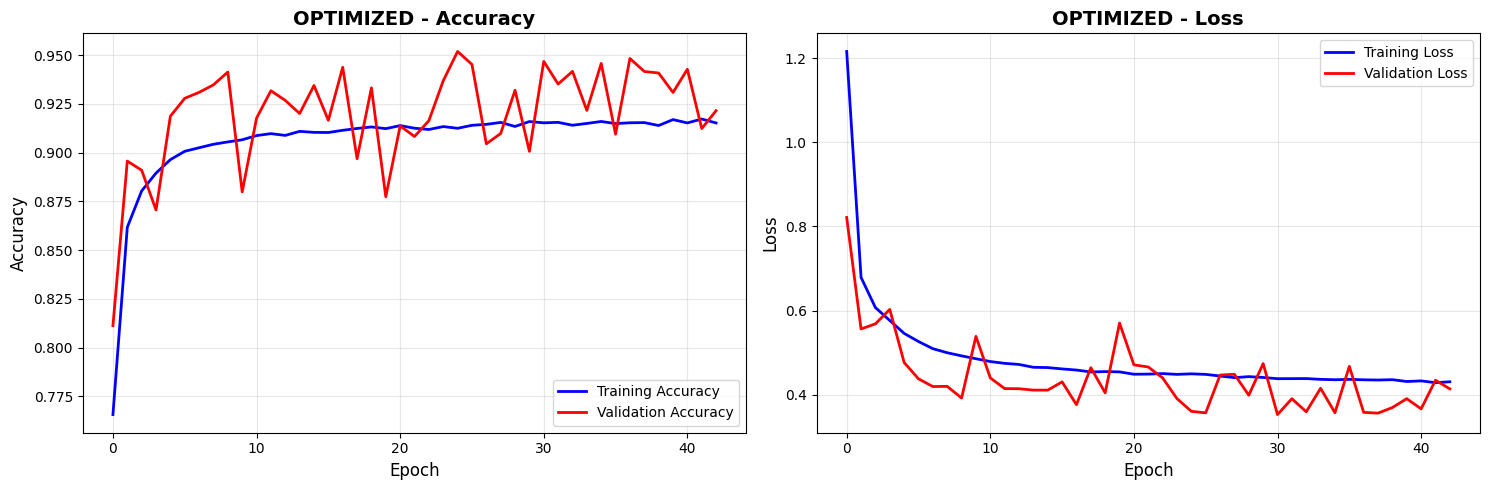


🔄 Running experiment: LIGHTWEIGHT

Training Model: lightweight
Model Configuration: lightweight


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs_cnn (InputLayer)         │ (None, 186, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 179, 32)        │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 87, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       180,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_output (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,157 (738.89 KB)

 Trainable params: 189,157 (738.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - accuracy: 0.6380 - loss: 0.9314 - val_accuracy: 0.8453 - val_loss: 0.4147
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 60ms/step - accuracy: 0.8371 - loss: 0.4482 - val_accuracy: 0.8744 - val_loss: 0.3227
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.8728 - loss: 0.3505 - val_accuracy: 0.9168 - val_loss: 0.2382
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.8926 - loss: 0.2955 - val_accuracy: 0.9238 - val_loss: 0.2144
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.9036 - loss: 0.2654 - val_accuracy: 0.9330 - val_loss: 0.1858
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.9120 - loss: 0.2438 - val_accuracy: 0.9419 - val_loss: 0.1678
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 62ms/step - accuracy: 0.9162 - loss: 0.2305 - val_accuracy: 0.9361 - val_loss: 0.1761
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 59ms/step - accuracy: 0.9171 - loss: 0.2258 - 

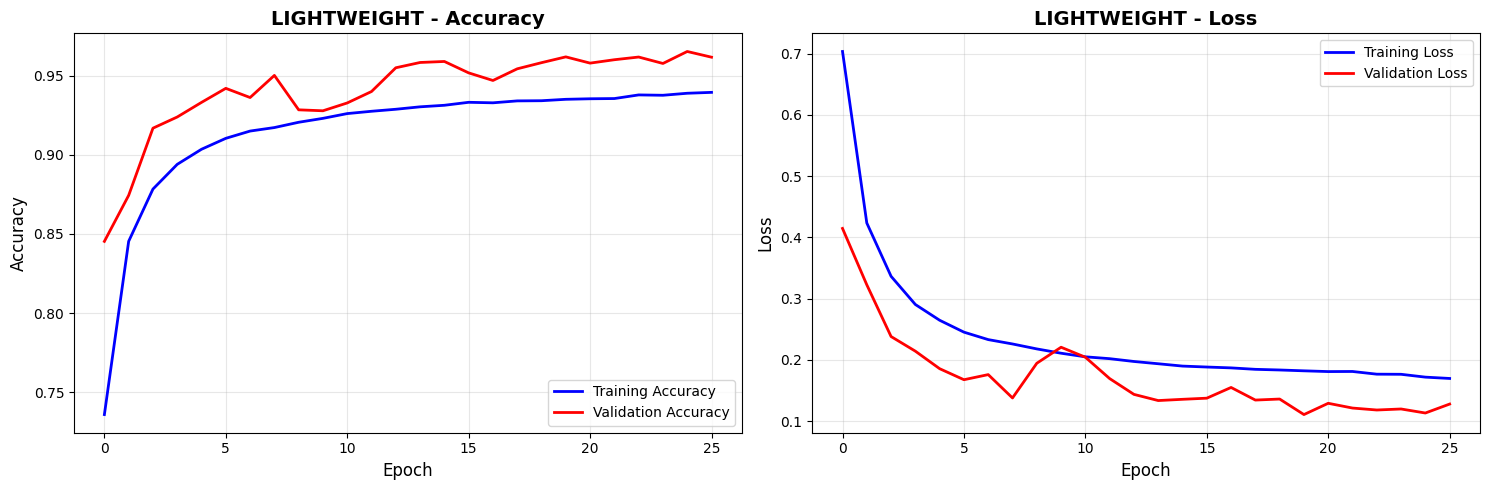


📊 COMPARING ALL MODELS

MODEL COMPARISON RESULTS
      Model Train Acc (%) Test Acc (%) Train Loss Test Loss Training Time (s)  Epochs
   baseline         97.18        97.41     0.0753    0.0899            2546.8      20
  optimized         93.91        94.68     0.3731    0.3529           18788.9      43
lightweight         95.50        96.18     0.1307    0.1109            1854.1      26


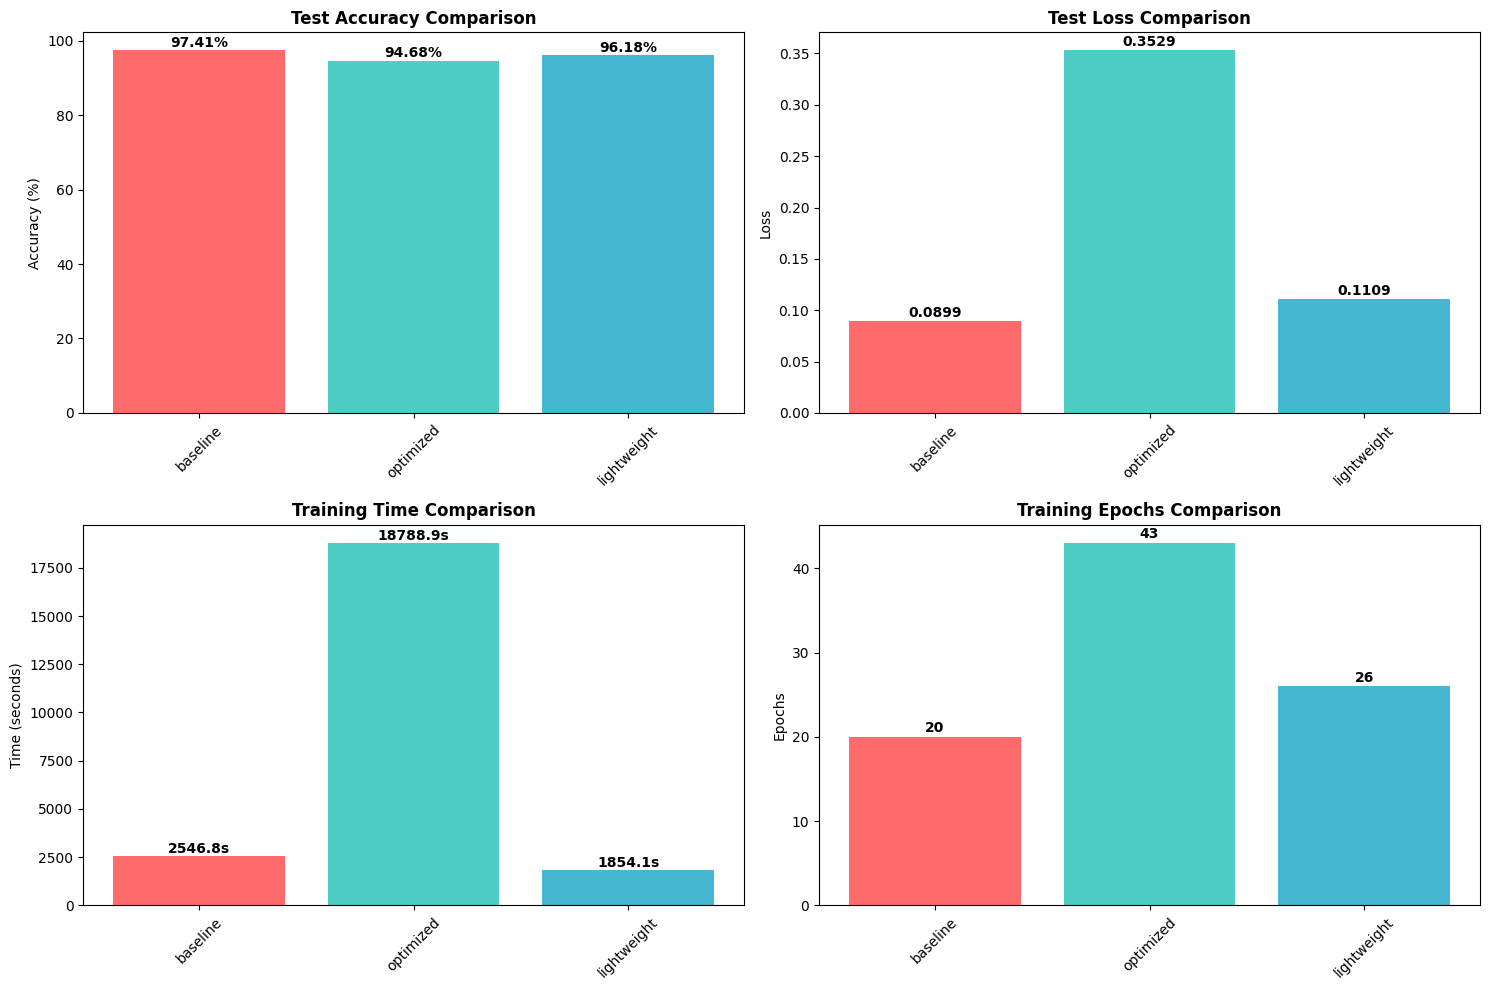


🏆 BEST MODEL: baseline
   Test Accuracy: 97.41%
   Training Time: 2546.8 seconds

🔍 HYPERPARAMETER ANALYSIS
----------------------------------------
Best configuration: baseline
Best hyperparameters:
  - Learning rate: 0.001
  - Batch size: 32
  - Optimizer: adam
  - Conv layers: 3
  - Dense layers: 2
  - Batch normalization: True

✅ Using BASELINE model for final evaluation


In [ ]:
"""# ===== PERUBAHAN 7: EKSPERIMEN HYPERPARAMETER TUNING =====
**Hyperparameter Tuning Experiments**"""

from keras.layers import Dense, Convolution1D, MaxPool1D, Flatten, Dropout
from keras.layers import Input
from keras.models import Model
from tensorflow.keras.layers import BatchNormalization
import keras
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Jalankan eksperimen untuk semua konfigurasi
print("🚀 STARTING HYPERPARAMETER TUNING EXPERIMENTS")
print("=" * 60)

models_results = []
trained_models = {}
model_histories = {}

# Pilih eksperimen mana yang akan dijalankan (ubah sesuai kebutuhan)
# Untuk demo, kita jalankan 3 model pertama untuk menghemat waktu
selected_experiments = ['baseline', 'optimized', 'lightweight']

for config_name in selected_experiments:
    print(f"\n🔄 Running experiment: {config_name.upper()}")

    config = experiment_configs[config_name]
    model, history, results = train_model_with_config(
        X_train, y_train, X_test, y_test, config, config_name
    )

    models_results.append(results)
    trained_models[config_name] = model
    model_histories[config_name] = history

    # Evaluate dengan detail
    evaluate_model_detailed(history, X_test, y_test, model, config_name.upper())

# Bandingkan semua model
print("\n📊 COMPARING ALL MODELS")
comparison_df = compare_models(models_results)

# Analisis hyperparameter terbaik
print("\n🔍 HYPERPARAMETER ANALYSIS")
print("-" * 40)
best_result = max(models_results, key=lambda x: x['test_accuracy'])
print(f"Best configuration: {best_result['model_name']}")
print("Best hyperparameters:")
best_config = best_result['config']
print(f"  - Learning rate: {best_config['learning_rate']}")
print(f"  - Batch size: {best_config['batch_size']}")
print(f"  - Optimizer: {best_config['optimizer']}")
print(f"  - Conv layers: {len(best_config['conv_layers'])}")
print(f"  - Dense layers: {len(best_config['dense_layers'])}")
print(f"  - Batch normalization: {best_config['use_batch_norm']}")

# Pilih model terbaik untuk evaluasi lanjutan
best_model_name = best_result['model_name']
best_model = trained_models[best_model_name]
best_history = model_histories[best_model_name]

print(f"\n✅ Using {best_model_name.upper()} model for final evaluation")

**Model Accuracy - Loss Evaluate, Confusion Matrix, ROC & AUC, Classification Report**


Evaluating Model: BASELINE
BASELINE - Test Accuracy: 97.41%
BASELINE - Test Loss: 0.0899


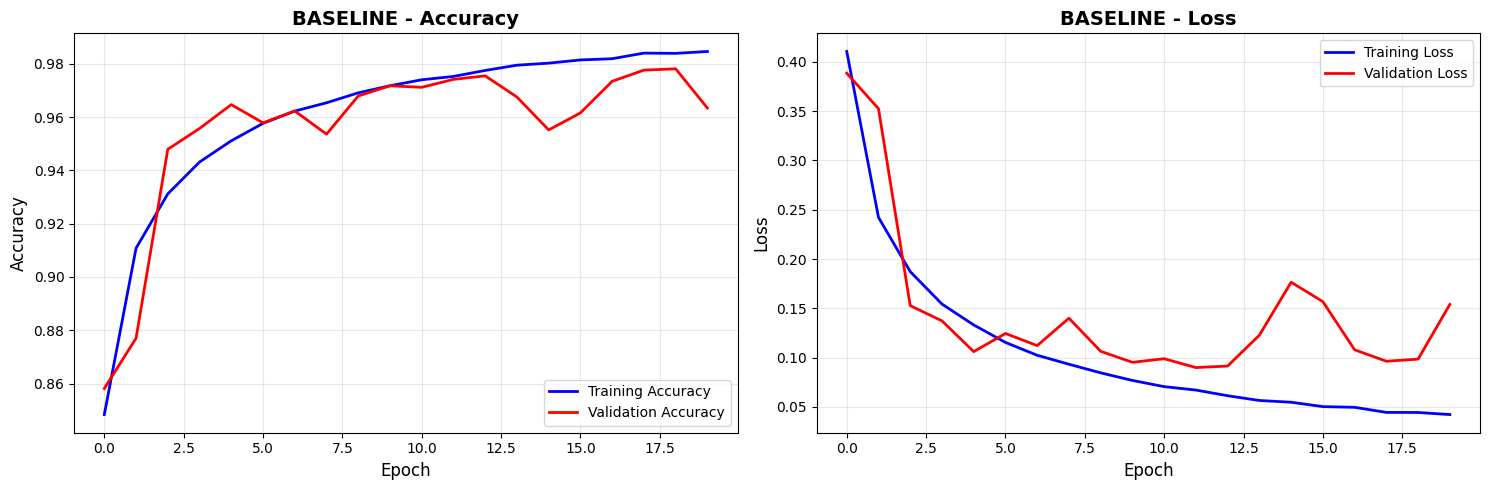

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step

BASELINE - Confusion Matrix:
Confusion matrix, without normalization


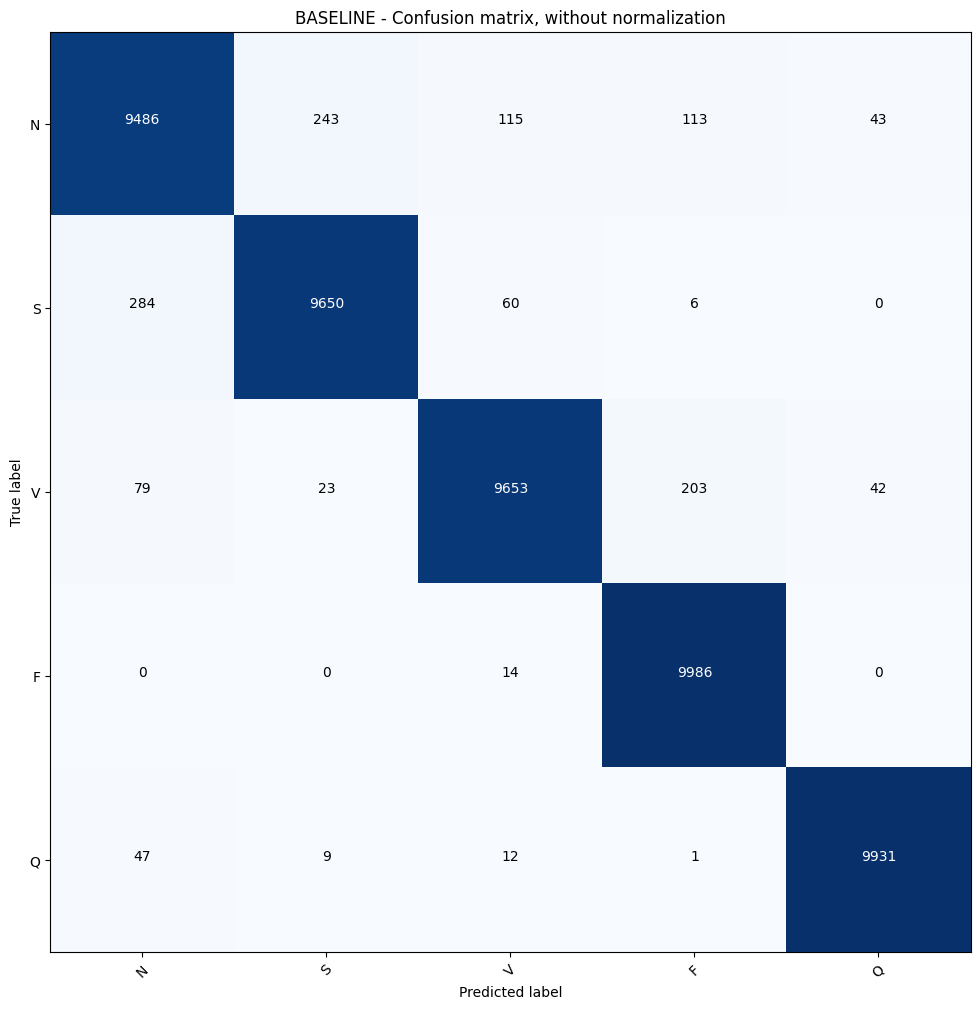


BASELINE - ROC and AUC:


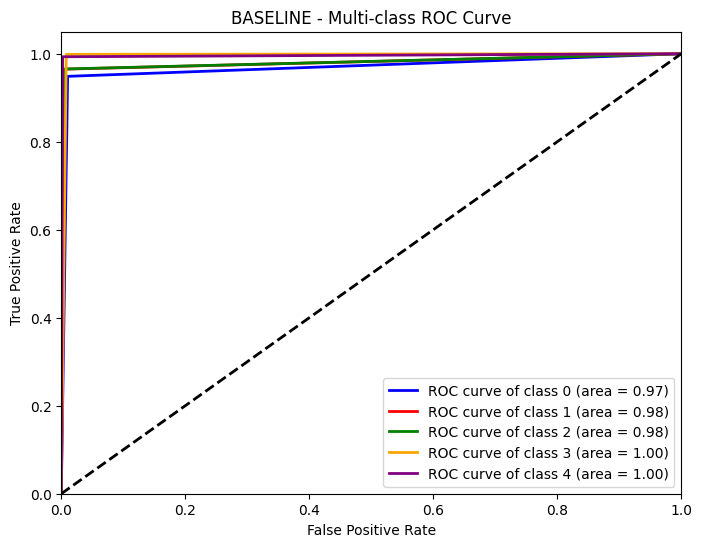


BASELINE - Classification Report:
              precision    recall  f1-score   support

           N       0.96      0.95      0.95     10000
           S       0.97      0.96      0.97     10000
           V       0.98      0.97      0.97     10000
           F       0.97      1.00      0.98     10000
           Q       0.99      0.99      0.99     10000

    accuracy                           0.97     50000
   macro avg       0.97      0.97      0.97     50000
weighted avg       0.97      0.97      0.97     50000


Evaluating Model: OPTIMIZED
OPTIMIZED - Test Accuracy: 94.68%
OPTIMIZED - Test Loss: 0.3529


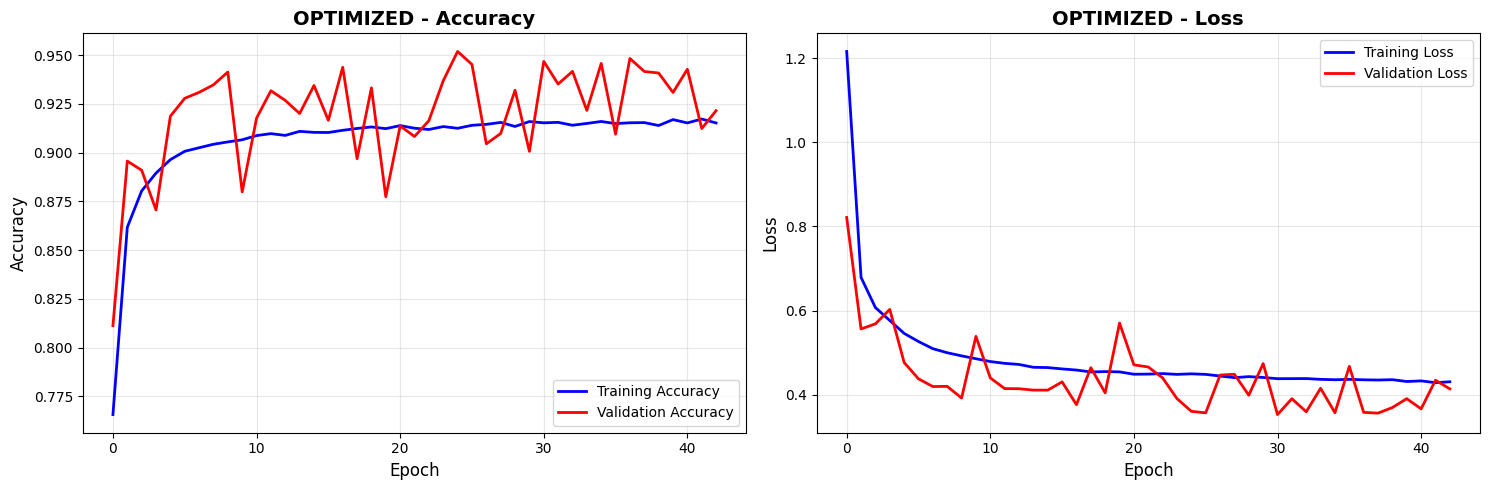

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step

OPTIMIZED - Confusion Matrix:
Confusion matrix, without normalization


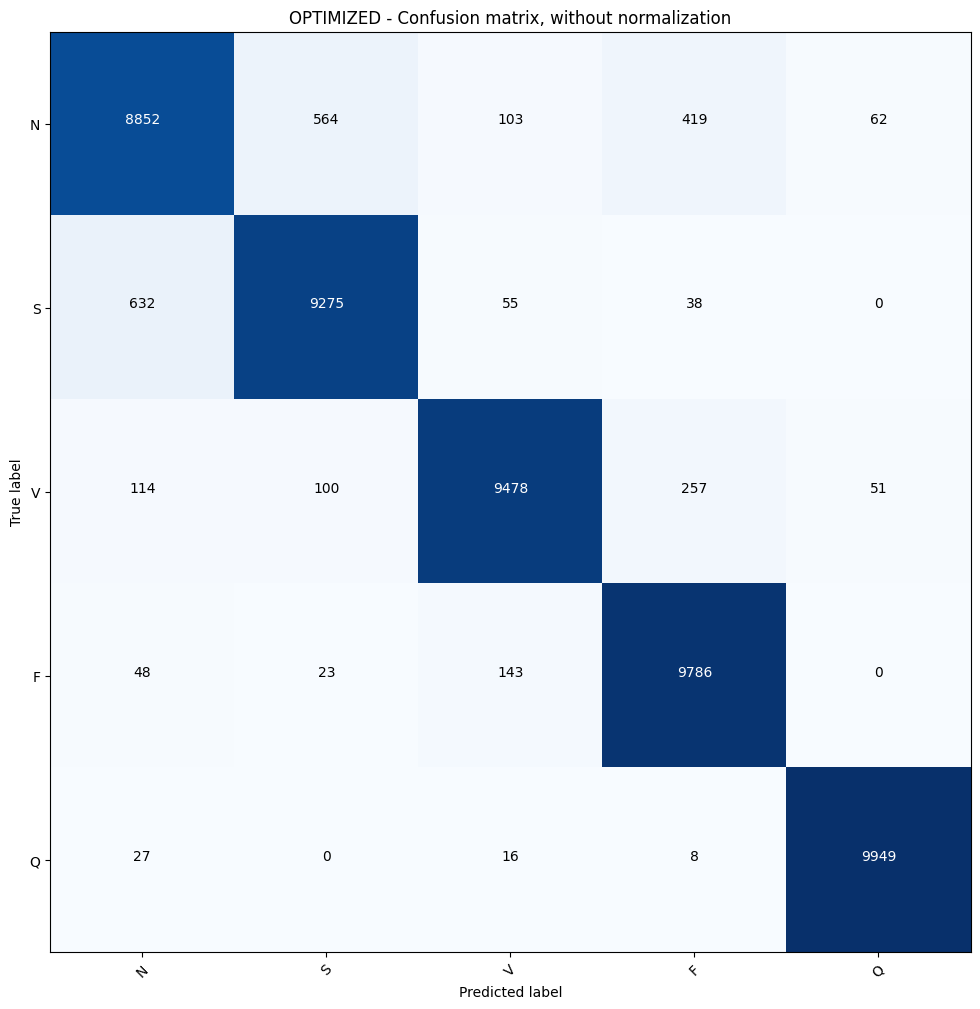


OPTIMIZED - ROC and AUC:


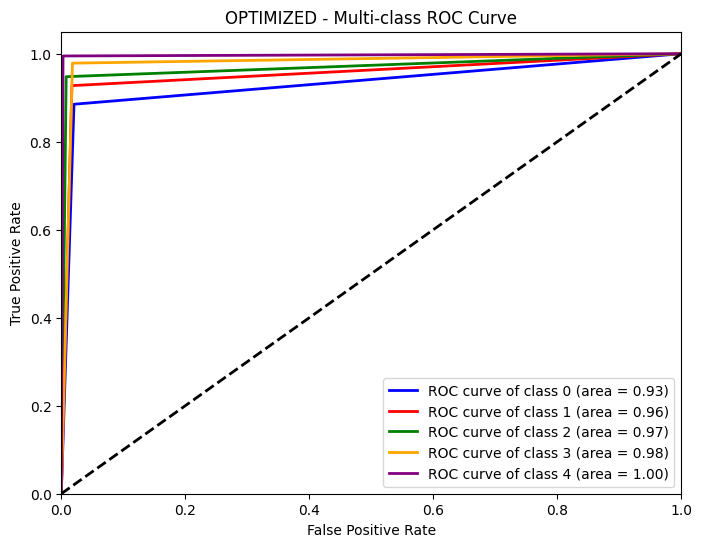


OPTIMIZED - Classification Report:
              precision    recall  f1-score   support

           N       0.92      0.89      0.90     10000
           S       0.93      0.93      0.93     10000
           V       0.97      0.95      0.96     10000
           F       0.93      0.98      0.95     10000
           Q       0.99      0.99      0.99     10000

    accuracy                           0.95     50000
   macro avg       0.95      0.95      0.95     50000
weighted avg       0.95      0.95      0.95     50000


Evaluating Model: LIGHTWEIGHT
LIGHTWEIGHT - Test Accuracy: 96.18%
LIGHTWEIGHT - Test Loss: 0.1109


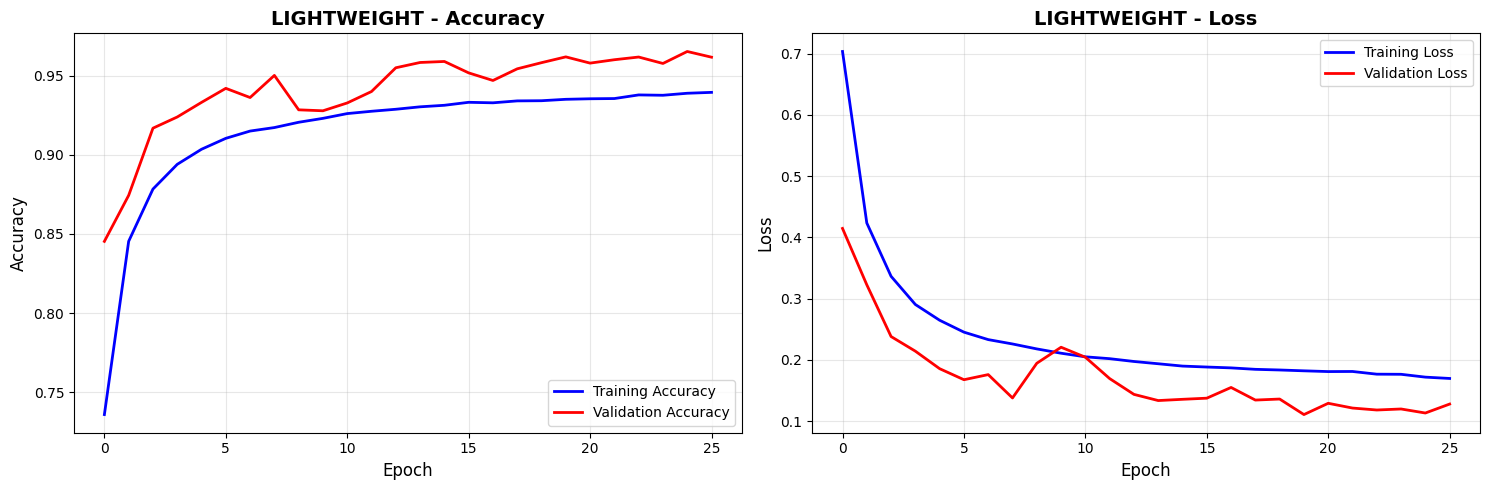

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step

LIGHTWEIGHT - Confusion Matrix:
Confusion matrix, without normalization


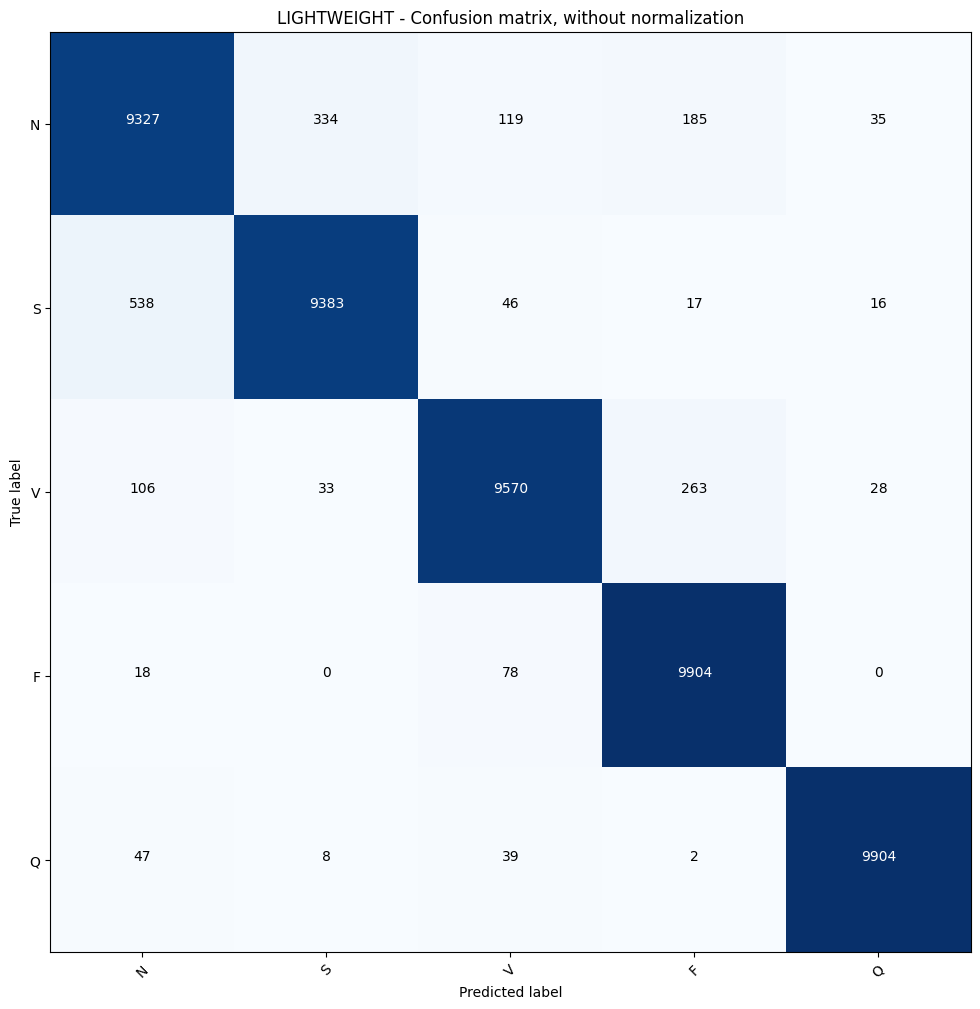


LIGHTWEIGHT - ROC and AUC:


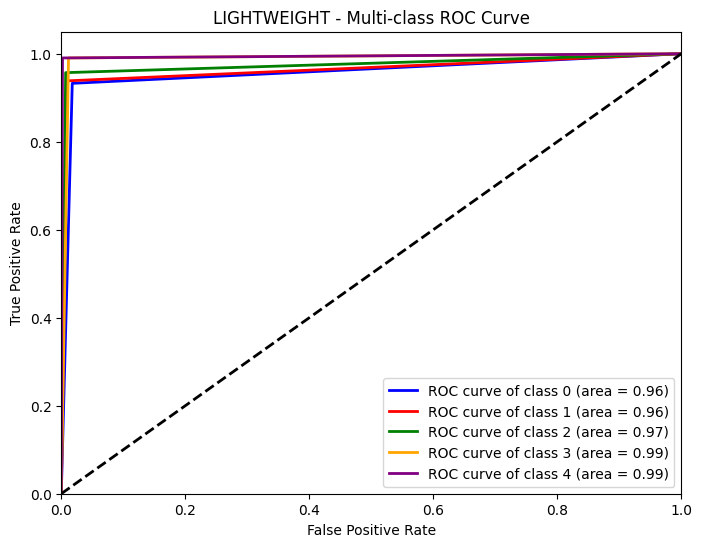


LIGHTWEIGHT - Classification Report:
              precision    recall  f1-score   support

           N       0.93      0.93      0.93     10000
           S       0.96      0.94      0.95     10000
           V       0.97      0.96      0.96     10000
           F       0.95      0.99      0.97     10000
           Q       0.99      0.99      0.99     10000

    accuracy                           0.96     50000
   macro avg       0.96      0.96      0.96     50000
weighted avg       0.96      0.96      0.96     50000



In [ ]:
# Evaluate and report for each selected model

# List of model names to evaluate
models_to_evaluate = selected_experiments # Using the list defined in the previous cell

for model_name in models_to_evaluate:
    print(f"\n{'='*50}")
    print(f"Evaluating Model: {model_name.upper()}")
    print(f"{'='*50}")

    model = trained_models[model_name]
    history = model_histories[model_name]

    # Evaluate model and show accuracy/loss plots
    evaluate_model_detailed(history, X_test, y_test, model, model_name.upper())

    # Predict probabilities and get predicted classes for confusion matrix and classification report
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = y_test.argmax(axis=1)


    # Confusion Matrix
    print(f"\n{model_name.upper()} - Confusion Matrix:")
    cnf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 10))
    plot_confusion_matrix(cnf_matrix, classes=['N', 'S', 'V', 'F', 'Q'], normalize=False,
                          title=f'{model_name.upper()} - Confusion matrix, without normalization')
    plt.show()


    # ROC and AUC
    print(f"\n{model_name.upper()} - ROC and AUC:")
    # Binarize label for multi-class ROC AUC
    y_test_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4])
    y_pred_bin = label_binarize(y_pred, classes=[0, 1, 2, 3, 4])
    n_classes = y_test_bin.shape[1]

    # Compute ROC and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve for each class
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(i, roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name.upper()} - Multi-class ROC Curve')
    plt.legend(loc="lower right")
    plt.show()


    # Classification Report
    print(f"\n{model_name.upper()} - Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['N', 'S', 'V', 'F', 'Q']))

**Final Model Evaluation with Best Hyperparameters**

FINAL BASELINE - Test Accuracy: 97.41%
FINAL BASELINE - Test Loss: 0.0899


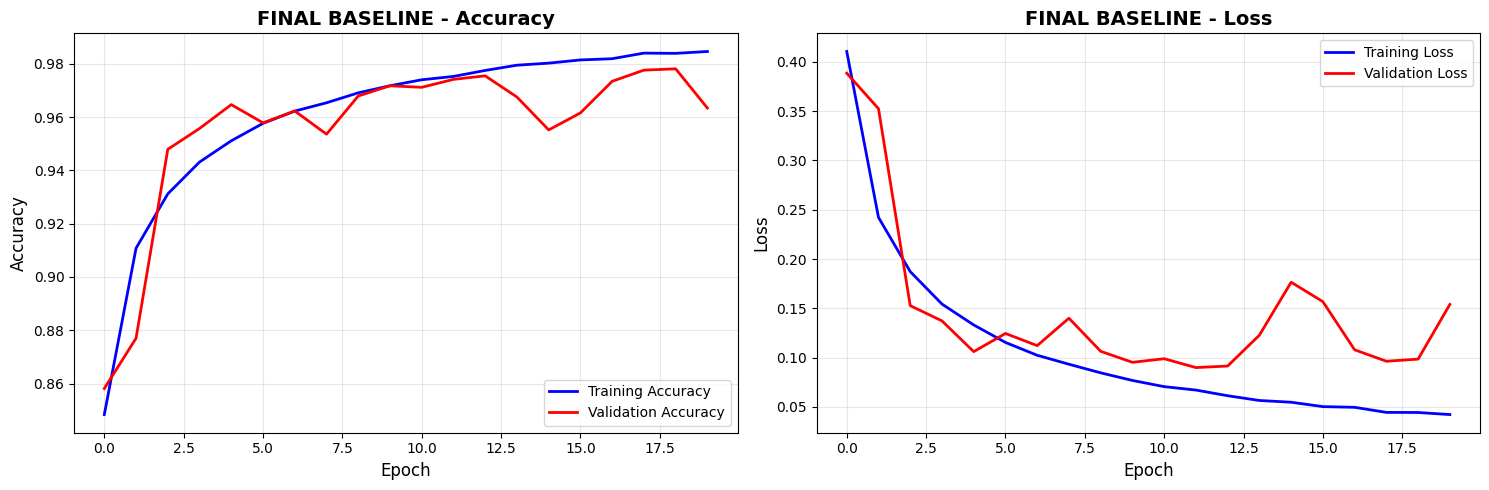

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step

FINAL RESULTS SUMMARY
Best Model: BASELINE
Final Test Accuracy: 97.41%
Final Test Loss: 0.0899
Model achieved 97.41% accuracy with intelligent ECG augmentation

Detailed configuration of baseline model:
Convolutional Layers:
  Layer 1: 64 filters, kernel=6, dropout=0
  Layer 2: 64 filters, kernel=3, dropout=0
  Layer 3: 64 filters, kernel=3, dropout=0
Dense Layers:
  Layer 1: 64 units, dropout=0
  Layer 2: 32 units, dropout=0
Optimizer: adam (lr=0.001)
Batch size: 32
Training epochs: 20
Training time: 2546.8 seconds


In [ ]:
"""**Final Model Evaluation with Best Hyperparameters**"""

# Evaluasi model terbaik
final_scores = evaluate_model_detailed(best_history, X_test, y_test, best_model, f"FINAL {best_model_name.upper()}")
y_pred = best_model.predict(X_test)

# Tampilkan ringkasan final
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Best Model: {best_model_name.upper()}")
print(f"Final Test Accuracy: {final_scores[1]*100:.2f}%")
print(f"Final Test Loss: {final_scores[0]:.4f}")
print(f"Model achieved {final_scores[1]*100:.2f}% accuracy with intelligent ECG augmentation")

# Detailed analysis untuk model terbaik
print(f"\nDetailed configuration of {best_model_name} model:")
best_config = best_result['config']
print("Convolutional Layers:")
for i, layer in enumerate(best_config['conv_layers']):
    print(f"  Layer {i+1}: {layer['filters']} filters, kernel={layer['kernel_size']}, dropout={layer.get('dropout', 0)}")
print("Dense Layers:")
for i, layer in enumerate(best_config['dense_layers']):
    print(f"  Layer {i+1}: {layer['units']} units, dropout={layer.get('dropout', 0)}")
print(f"Optimizer: {best_config['optimizer']} (lr={best_config['learning_rate']})")
print(f"Batch size: {best_config['batch_size']}")
print(f"Training epochs: {best_result['total_epochs']}")
print(f"Training time: {best_result['training_time']:.1f} seconds")